# ADABoost

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10

2026-04-03 10:50:06.885437: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-03 10:50:07.536689: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [7]:
data = cifar10.load_data()

170498071/170498071 [==============================] - 576s 3us/step


In [10]:
data[0][0].shape

(50000, 32, 32, 3)

In [11]:
data[0][1].shape

(50000, 1)

In [12]:
data[1][0].shape

(10000, 32, 32, 3)

In [13]:
data[1][1].shape

(10000, 1)

In [14]:
X = np.concatenate((data[0][0], data[1][0]), axis=0)

In [15]:
y = np.concatenate((data[0][1], data[1][1]), axis=0)

In [17]:
X.shape

(60000, 32, 32, 3)

In [18]:
y.shape

(60000, 1)

In [20]:
np.unique(y)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [34]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
cls_mask = np.isin(y.flatten(), [0, 1, 8, 9])

In [35]:
X.shape, y.flatten().shape

((60000, 32, 32, 3), (60000,))

In [36]:
X_filtered = X[cls_mask]
y_filtered = y.flatten()[cls_mask]

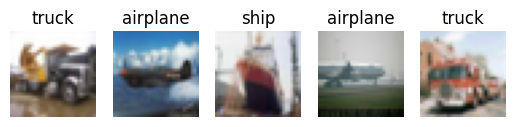

In [61]:
import random

for i, idx in enumerate(random.sample(range(len(X_filtered)), 5)):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_filtered[idx])
    plt.title(class_names[y_filtered[idx]])
    plt.axis('off')

In [37]:
X_filtered.shape

(24000, 32, 32, 3)

In [38]:
y_filtered.shape

(24000,)

In [42]:
from skimage.feature import hog
from tqdm import tqdm

In [43]:
X_hog = []

In [44]:
for img in tqdm(X_filtered):
    fd = hog(img, orientations=9, pixels_per_cell=(8, 8),
                cells_per_block=(2, 2), channel_axis=-1)
    X_hog.append(fd)

X_hog = np.array(X_hog) 

100%|██████████| 24000/24000 [00:26<00:00, 916.71it/s] 


In [45]:
X_hog.shape

(24000, 324)

In [48]:
X_hog[0][:10]

array([0.2146412 , 0.13993964, 0.21727524, 0.24043551, 0.25952464,
       0.06657891, 0.02158709, 0.02241527, 0.03305315, 0.13767251])

In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_hog, y_filtered, test_size=0.2, random_state=42)

<p>ADA Boost Classifier imported</p>

In [50]:
from sklearn.ensemble import AdaBoostClassifier

In [73]:
model = AdaBoostClassifier(n_estimators=500, learning_rate=0.5, random_state=42, algorithm='SAMME')

In [74]:
model.fit(X_train, y_train)

AdaBoostClassifier(algorithm='SAMME', learning_rate=0.5, n_estimators=500,
                   random_state=42)

In [123]:
import cv2
display_classes = [class_names[i] for i in [0, 1, 8, 9]]
def evaluate_with_external_data(path, model, class_names):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img_resized = cv2.resize(img, (32, 32))
    fd = hog(img_resized, orientations=9, pixels_per_cell=(8, 8),
                cells_per_block=(2, 2), channel_axis=-1)
    fd = fd.reshape(1, -1)
    probabilities = model.predict_proba(fd)[0]
    prediction = model.predict(fd)[0]
    
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(img_resized)
    plt.title(f'Predicted: {class_names[prediction]}')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    classes = list(display_classes)
    plt.barh(classes, probabilities, color='skyblue')
    plt.xlabel('Probability')
    plt.title('Class Probabilities')

    for i, prob in enumerate(probabilities):
        print(f"{display_classes[i]}: {prob*100:.2f}%")


airplane: 25.73%
automobile: 24.34%
ship: 25.81%
truck: 24.12%


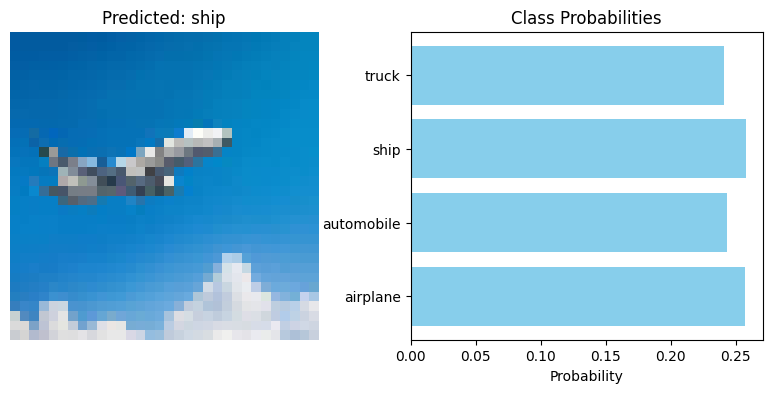

In [ ]:
evaluate_with_external_data('data/sample.jpeg', model, class_names)

In [125]:
X_test[:1]

array([[0.05154458, 0.01637782, 0.02109584, 0.00773926, 0.04170509,
        0.01821768, 0.01623396, 0.01680677, 0.01536979, 0.01730551,
        0.00154785, 0.01076842, 0.0059498 , 0.02076661, 0.0030957 ,
        0.00293684, 0.        , 0.        , 0.3165773 , 0.18561492,
        0.23551842, 0.32153943, 0.35723716, 0.35723716, 0.35518021,
        0.03972284, 0.06090426, 0.05347135, 0.00372772, 0.14753318,
        0.35723716, 0.35723716, 0.12842297, 0.11370512, 0.0344862 ,
        0.04604069, 0.0148765 , 0.00133059, 0.00925696, 0.00511469,
        0.0178518 , 0.00266119, 0.00252463, 0.        , 0.        ,
        0.08484847, 0.0104432 , 0.00336617, 0.00509409, 0.00714072,
        0.00133059, 0.        , 0.        , 0.00894571, 0.0459661 ,
        0.0032045 , 0.12682537, 0.39860461, 0.39860461, 0.11039748,
        0.09774543, 0.0296457 , 0.03957841, 0.03428228, 0.37637729,
        0.39860461, 0.39860461, 0.39860461, 0.00133059, 0.00168308,
        0.02514349, 0.10751518, 0.06952704, 0.00

In [126]:
random_indices = random.sample(range(len(X_test)), 10)

In [127]:
random_indices

[33, 710, 2112, 3568, 2795, 2986, 4466, 1860, 2144, 2709]

In [128]:
model.predict(X_test[random_indices])

array([9, 0, 1, 9, 0, 8, 8, 1, 1, 9], dtype=uint8)

In [129]:
y_test[random_indices]

array([9, 1, 8, 9, 0, 1, 0, 8, 1, 9], dtype=uint8)

In [133]:
total_result = []
for k in range(100):
    random_indices = random.sample(range(len(X_test)), 10)
    correct = 0
    total = len(random_indices)
    pred = model.predict(X_test[random_indices])
    for i in range(total):
        if pred[i].reshape(1, -1)[0] == y_test[random_indices[i]]:
            correct += 1
    accuracy = correct / total
    total_result.append(accuracy)
print(f"Average Accuracy: {np.mean(total_result)*100:.2f}%")

Average Accuracy: 66.40%


In [134]:
pred = model.predict(X_test)
pred

array([0, 1, 1, ..., 0, 1, 0], dtype=uint8)

In [135]:
correct = 0
for i in range(len(X_test)):
    if pred[i] == y_test[i]:
        correct += 1
accuracy = correct / len(X_test)


In [136]:
f"{accuracy:.2%}"

'66.21%'

In [137]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

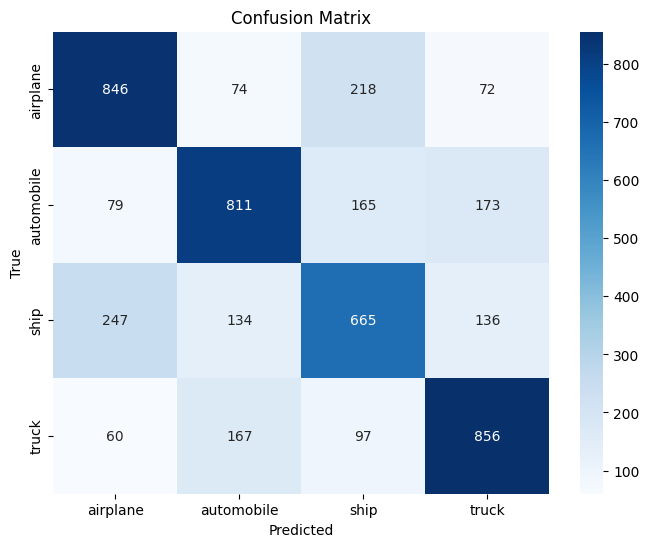

In [138]:
cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=display_classes, yticklabels=display_classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

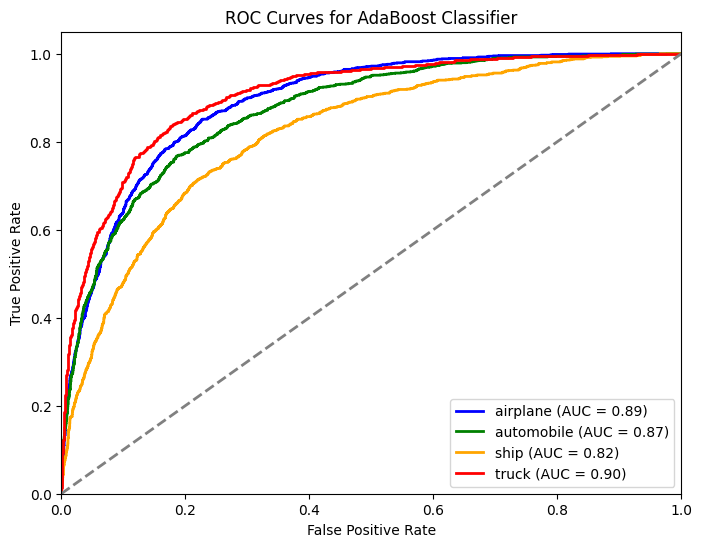

In [142]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[0, 1, 8, 9])
n_classes = y_test_bin.shape[1]

y_score = model.predict_proba(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
colors = ['blue', 'green', 'orange', 'red']
for i, color in enumerate(colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{display_classes[i]} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for AdaBoost Classifier')
plt.legend(loc='lower right')
plt.show()